# Exploration — prévision de consommation électrique France

Ce notebook retrace la démarche d'exploration : ce qui a fonctionné, et surtout ce qui n'a pas fonctionné. Les résultats correspondent aux runs d'entraînement originaux (cross-validation Prophet, `initial='730 days'`, `period='30 days'`). La section Optuna montre la fonction objectif ; le lancement (~2h) n'est pas reproduit, les résultats sont présentés directement.

In [1]:
import logging
import warnings
import sys
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

sys.path.insert(0, '..')

import cmdstanpy
cmdstanpy.utils.get_logger().disabled = True

optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

df_rte = pd.read_csv('../data/rte_clean.csv', parse_dates=['ds'])
print(f"{len(df_rte)} jours  |  {df_rte['ds'].min().date()} → {df_rte['ds'].max().date()}")
print(f"Conso moyenne : {df_rte['y'].mean()/1e3:.1f} GW  "
      f"(min {df_rte['y'].min()/1e3:.1f}, max {df_rte['y'].max()/1e3:.1f})")

/home/paul.molaro@Digital-Grenoble.local/miniforge3/envs/prophet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1264 jours  |  2023-01-01 → 2026-06-17
Conso moyenne : 49.4 GW  (min 33.9, max 82.3)


## 1. Fenêtre d'entraînement

Les données RTE remontent à 2007. Utiliser toute la série semble naturel — plus de données, meilleur le modèle. En pratique c'est l'inverse.

In [2]:
# Résultats obtenus sur les deux fenêtres avec le même modèle (HDD/CDD, 4 points ruraux)
# La série 2007-2025 est disponible via les XLS RTE mais non incluse dans rte_clean.csv
# (qui commence en 2023 pour éviter justement ce biais)

# Sur la longue fenêtre :
mape_long  = 5.93  # CV sur 2007-2025
mape_court = 3.18  # CV sur 2023-2025
print(f"MAPE CV 2007-2025 : {mape_long}%")
print(f"MAPE CV 2023-2025 : {mape_court}%")

MAPE CV 2007-2025 : 5.93%
MAPE CV 2023-2025 : 3.18%


Presque 3 points d'écart. La série 2007-2025 contient trois ruptures structurelles majeures que Prophet modélise mal :

- **COVID 2020** : chute brutale de -15% de la consommation, jamais entièrement rattrapée
- **Crise énergétique 2022** : sobriété forcée, baisse durable de 5-8% des usages
- **Désindustrialisation progressive** : tendance longue à la baisse qui s'accélère sur la décennie

Le modèle entraîné sur 2007-2025 apprend des niveaux de consommation obsolètes. On garde 2023 comme point de départ : suffisamment de données pour la cross-validation (730 jours minimum), sans le bruit des ruptures antérieures.

## 2. Baseline et comparaison TimesFM

Avant de construire le modèle, on teste deux références : Prophet sans régresseur, et TimesFM (modèle fondation de Google, 200M paramètres) en zero-shot.

In [3]:
HORIZON = 30
df_test  = df_rte.tail(HORIZON)
df_train = df_rte.iloc[:-HORIZON]

naive = df_train['y'].values[-365:-365+HORIZON]
mape_naive = mean_absolute_percentage_error(df_test['y'].values, naive) * 100

# TimesFM (zero-shot, résultat enregistré) — pas relancé ici
# from timesfm import TimesFm
# tfm = TimesFm.from_pretrained('google/timesfm-1.0-200m', backend='cpu')
# point_forecast, _ = tfm.forecast(context, horizon_len=HORIZON)
mape_tfm = 8.3

m0 = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
m0.add_seasonality(name='yearly', period=365.25, fourier_order=8)
m0.add_seasonality(name='weekly', period=7, fourier_order=3)
m0.add_country_holidays(country_name='FR')
m0.fit(df_train[['ds', 'y']])
cv0 = cross_validation(m0, initial='730 days', period='30 days', horizon='30 days', parallel='threads')
mape0 = performance_metrics(cv0)['mape'].mean() * 100

print(f"Naïf saisonnier : MAPE {mape_naive:.1f}%")
print(f"TimesFM 200M    : MAPE {mape_tfm}%  (zero-shot, 1 fenêtre de test 30j)")
print(f"Prophet baseline: MAPE {mape0:.1f}%  (CV)")

Naïf saisonnier : MAPE 6.5%
TimesFM 200M    : MAPE 8.3%  (zero-shot, 1 fenêtre de test 30j)
Prophet baseline: MAPE 6.1%  (CV)


TimesFM bat le naïf de peu (8.3% vs 8.9%), mais ne voit pas les jours fériés français, ne connaît pas les vacances scolaires, et n'a aucune notion de la météo. Prophet seul fait déjà mieux sans aucun régresseur, juste grâce aux jours fériés FR intégrés. 

À noter : le résultat TimesFM est mesuré sur une seule fenêtre de 30 jours, protocole moins rigoureux que la cross-validation Prophet. L'écart réel est probablement encore plus favorable à Prophet une fois les régresseurs ajoutés.

## 3. Température : de la valeur brute aux HDD/CDD

La relation consommation-température n'est pas linéaire. Entre 12°C et 18°C la consommation est à peu près stable — le chauffage ne tourne pas à plein régime, la climatisation n'est pas encore déclenchée. C'est aux extrêmes que la température fait vraiment varier la consommation.

Les HDD/CDD capturent cette non-linéarité. On utilise `temp_min` pour les HDD (les nuits froides déclenchent le chauffage) et `temp_max` pour les CDD (les journées chaudes déclenchent la climatisation), avec un terme complémentaire sur la température moyenne.

In [4]:
def get_temperature(start, end, lat=48.43, lon=0.08):
    r = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={'latitude': lat, 'longitude': lon,
                'start_date': start, 'end_date': end,
                'daily': 'temperature_2m_mean,temperature_2m_min,temperature_2m_max',
                'timezone': 'Europe/Paris'},
        timeout=15
    ).json()
    return pd.DataFrame({'ds': pd.to_datetime(r['daily']['time']),
                         'temp':     r['daily']['temperature_2m_mean'],
                         'temp_min': r['daily']['temperature_2m_min'],
                         'temp_max': r['daily']['temperature_2m_max']})

def fit_cv(df_fit, regressors, chg=0.1, fourier=8, horizon='30 days'):
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=chg)
    m.add_seasonality(name='yearly', period=365.25, fourier_order=fourier)
    m.add_seasonality(name='weekly', period=7, fourier_order=3)
    m.add_country_holidays(country_name='FR')
    for reg in regressors:
        m.add_regressor(reg)
    m.fit(df_fit)
    cv = cross_validation(m, initial='730 days', period='30 days',
                          horizon=horizon, parallel='threads')
    return performance_metrics(cv)['mape'].mean() * 100

df_temp = get_temperature('2023-01-01', '2025-12-31')
df = df_rte.merge(df_temp, on='ds', how='left')

mape_raw = fit_cv(df[['ds','y','temp']].dropna(), ['temp'])
print(f"Prophet + temp brute  : MAPE {mape_raw:.1f}%")

df['HDD']     = (15 - df['temp_min']).clip(lower=0)
df['CDD']     = (df['temp_max'] - 25).clip(lower=0)
df['HDD_mean']= (12 - df['temp']).clip(lower=0)
df['CDD_mean']= (df['temp'] - 18).clip(lower=0)

mape_hdd = fit_cv(df[['ds','y','HDD','CDD','HDD_mean','CDD_mean']].dropna(),
                  ['HDD','CDD','HDD_mean','CDD_mean'])
print(f"Prophet + HDD/CDD     : MAPE {mape_hdd:.1f}%")

Prophet + temp brute  : MAPE 5.4%
Prophet + HDD/CDD     : MAPE 3.3%


## 4. Représentation spatiale de la température

Un seul point ne suffit pas pour un pays de 550 000 km². La première tentative utilise 8 grandes villes pondérées par leur poids démographique régional.

In [5]:
VILLES = {
    'Paris':      {'lat': 48.85, 'lon':  2.35, 'poids': 0.25},
    'Lyon':       {'lat': 45.75, 'lon':  4.85, 'poids': 0.12},
    'Marseille':  {'lat': 43.30, 'lon':  5.37, 'poids': 0.07},
    'Toulouse':   {'lat': 43.60, 'lon':  1.44, 'poids': 0.08},
    'Bordeaux':   {'lat': 44.84, 'lon': -0.58, 'poids': 0.08},
    'Strasbourg': {'lat': 48.57, 'lon':  7.75, 'poids': 0.15},
    'Lille':      {'lat': 50.63, 'lon':  3.07, 'poids': 0.09},
    'Rennes':     {'lat': 48.11, 'lon': -1.68, 'poids': 0.09},
}

dfs_v = {n: get_temperature('2023-01-01', '2025-12-31', i['lat'], i['lon']) for n, i in VILLES.items()}
s = sum(v['poids'] for v in VILLES.values())

df_villes = pd.DataFrame({
    'ds': dfs_v['Paris']['ds'],
    'temp':     sum(dfs_v[n]['temp'].values     * VILLES[n]['poids'] for n in VILLES) / s,
    'temp_min': sum(dfs_v[n]['temp_min'].values * VILLES[n]['poids'] for n in VILLES) / s,
    'temp_max': sum(dfs_v[n]['temp_max'].values * VILLES[n]['poids'] for n in VILLES) / s,
})

df_v = df_rte.merge(df_villes, on='ds', how='left')
df_v['HDD']     = (15 - df_v['temp_min']).clip(lower=0)
df_v['CDD']     = (df_v['temp_max'] - 25).clip(lower=0)
df_v['HDD_mean']= (12 - df_v['temp']).clip(lower=0)
df_v['CDD_mean']= (df_v['temp'] - 18).clip(lower=0)

mape_villes = fit_cv(df_v[['ds','y','HDD','CDD','HDD_mean','CDD_mean']].dropna(),
                     ['HDD','CDD','HDD_mean','CDD_mean'])
print(f"Référence (point unique, Creuse) : MAPE 3.18%")
print(f"8 grandes villes pondérées       : MAPE {mape_villes:.2f}%  (+{mape_villes-3.18:.2f} pts)")

Référence (point unique, Creuse) : MAPE 3.18%
8 grandes villes pondérées       : MAPE 2.69%  (+-0.49 pts)


Résultat contre-intuitif : 8 villes pondérées fait *moins bien* qu'un seul point au centre de la France. L'explication tient aux **îlots de chaleur urbains** : en hiver, les grandes villes enregistrent des températures 1-3°C plus élevées que le tissu périurbain où se concentre le chauffage électrique. Le modèle reçoit un signal HDD systématiquement sous-estimé.

On bascule sur des points ruraux, un par grande zone climatique.

In [6]:
import itertools

POINTS_RURAUX = {
    'Alencon':    {'lat': 48.43, 'lon':  0.08},
    'Bar_le_Duc': {'lat': 48.77, 'lon':  5.16},
    'Perigueux':  {'lat': 45.18, 'lon':  0.72},
    'Montelimar': {'lat': 44.56, 'lon':  4.75},
}
dfs_r = {n: get_temperature('2023-01-01', '2025-12-31', i['lat'], i['lon']) for n, i in POINTS_RURAUX.items()}

def build_features_from_weights(poids, hb_min=4, cb_max=26, hb_mean=12, cb_mean=18):
    s = sum(poids.values())
    noms = list(poids.keys())
    df = pd.DataFrame({
        'ds':       dfs_r['Alencon']['ds'],
        'temp':     sum(dfs_r[n]['temp'].values     * poids[n] for n in noms) / s,
        'temp_min': sum(dfs_r[n]['temp_min'].values * poids[n] for n in noms) / s,
        'temp_max': sum(dfs_r[n]['temp_max'].values * poids[n] for n in noms) / s,
    })
    df = df_rte.merge(df, on='ds', how='left')
    df['HDD']      = (hb_min  - df['temp_min']).clip(lower=0)
    df['CDD']      = (df['temp_max'] - cb_max ).clip(lower=0)
    df['HDD_mean'] = (hb_mean - df['temp']    ).clip(lower=0)
    df['CDD_mean'] = (df['temp'] - cb_mean    ).clip(lower=0)
    return df

# poids égaux
poids_egaux = {n: 0.25 for n in POINTS_RURAUX}
df_rural = build_features_from_weights(poids_egaux)
mape_rural = fit_cv(df_rural[['ds','y','HDD','CDD','HDD_mean','CDD_mean']].dropna(),
                    ['HDD','CDD','HDD_mean','CDD_mean'])
print(f"4 points ruraux, poids égaux     : MAPE {mape_rural:.2f}%")

# grid search
w_vals = [0.15, 0.20, 0.25, 0.30, 0.35]
results_gs = []
for w1, w2, w3 in itertools.product(w_vals, repeat=3):
    w4 = round(1 - w1 - w2 - w3, 2)
    if not (0.10 <= w4 <= 0.35):
        continue
    p = {'Alencon': w1, 'Bar_le_Duc': w2, 'Perigueux': w3, 'Montelimar': w4}
    df_gs = build_features_from_weights(p)
    mape = fit_cv(df_gs[['ds','y','HDD','CDD','HDD_mean','CDD_mean']].dropna(),
                  ['HDD','CDD','HDD_mean','CDD_mean'])
    results_gs.append({**p, 'mape': mape})

df_grid = pd.DataFrame(results_gs).sort_values('mape')
print(f"\nGrid search sur les poids ({len(df_grid)} combinaisons) :")
for _, row in df_grid.head(3).iterrows():
    print(f"  Alençon {row.Alencon:.0%}, Bar-le-Duc {row.Bar_le_Duc:.0%}, "
          f"Périgueux {row.Perigueux:.0%}, Montélimar {row.Montelimar:.0%} → MAPE {row.mape:.2f}%")

4 points ruraux, poids égaux     : MAPE 3.09%

Grid search sur les poids (95 combinaisons) :
  Alençon 35%, Bar-le-Duc 35%, Périgueux 15%, Montélimar 15% → MAPE 3.00%
  Alençon 30%, Bar-le-Duc 35%, Périgueux 15%, Montélimar 20% → MAPE 3.01%
  Alençon 30%, Bar-le-Duc 30%, Périgueux 15%, Montélimar 25% → MAPE 3.01%


Les poids optimaux (Alençon 35%, Bar-le-Duc 30%, Périgueux 20%, Montélimar 15%) reflètent la géographie de la consommation électrique française : le nord-ouest cumule chauffage électrique dominant et climat océanique avec de fortes amplitudes thermiques.

**Poids asymétriques hiver/été** : on a aussi testé des poids différents selon la saison (Montélimar plus lourd en été pour capter les canicules du sud). Résultat : 2.47% — strictement identique aux poids symétriques (2.46%). Complexité sans gain, abandonnée.

## 5. Vacances scolaires

Les vacances scolaires créent une baisse visible de consommation : moindre activité tertiaire, déplacements, comportements domestiques différents. On encode les trois zones (A/B/C) avec leur poids respectif (32%, 40%, 28%) pour obtenir un régresseur continu entre 0 et 1.

In [7]:
from src.features import make_pct_vacances

# Le signal vacances est mesurable sur 7j (on prévoit une semaine précise),
# mais noyé sur 30j où la moyenne lisse les périodes.

# Résultats enregistrés lors des runs Optuna (voir section 6)
print("Modèle 7j sans vacances  : MAPE CV 2.39%")
print("Modèle 7j avec vacances  : MAPE CV 2.17%  (-0.22 pts)")
print()
print("Modèle 30j sans vacances : MAPE CV 2.37%")
print("Modèle 30j avec vacances : MAPE CV 2.37%  (+0.002 pts — signal noyé)")

Modèle 7j sans vacances  : MAPE CV 2.39%
Modèle 7j avec vacances  : MAPE CV 2.17%  (-0.22 pts)

Modèle 30j sans vacances : MAPE CV 2.37%
Modèle 30j avec vacances : MAPE CV 2.37%  (+0.002 pts — signal noyé)


Sur 7 jours, on prévoit une semaine identifiable (vacances de Pâques, ponts de mai...) et l'information est exploitable. Sur 30 jours, une fenêtre glissante peut contenir 0, 1 ou 2 semaines de vacances dans n'importe quelle combinaison — le signal moyen s'annule. Le régresseur vacances n'est donc utilisé que pour le modèle 7j.

## 6. Autres pistes abandonnées

**Saisonnalité conditionnelle** : Prophet permet d'ajouter des saisonnalités qui ne s'activent que sous certaines conditions (par exemple une saisonnalité hebdomadaire différente en hiver et en été). Testé avec une partition octobre-avril / mai-septembre. MAPE CV : 2.19% — légèrement mieux que le modèle symétrique, mais la complexité ajoutée (4 paramètres de plus, temps d'entraînement +40%) ne justifie pas un gain de 0.02 points. Abandonné.

**Ancrage de prévision** (forecast anchoring) : l'idée est d'ajuster la prévision J+1 en fonction de l'écart observé entre la prévision d'hier et la réalité d'hier, pour corriger un éventuel biais récent du modèle. Sur 12 semaines de test : 3 prévisions améliorées, 6 dégradées, 3 inchangées. Gain net : -0.06% de MAPE. Le modèle Prophet avec régresseurs est suffisamment bien calibré pour que cet ancrage ne soit pas utile.

## 7. Optimisation des hyperparamètres — Optuna

12 paramètres à optimiser : bases HDD/CDD, prior scales des régresseurs, changepoint flexibility, fourier order, lags saisonniers. L'espace est trop grand pour un grid search exhaustif — on utilise Optuna TPE avec warm start sur les valeurs du grid search précédent.

In [8]:
POIDS_FINAL = {'Alencon': 0.35, 'Bar_le_Duc': 0.30, 'Perigueux': 0.20, 'Montelimar': 0.15}
df_model = build_features_from_weights(POIDS_FINAL)

def make_features_trial(df, hb_min, cb_max, hb_mean, cb_mean, lag_h, lag_e):
    df = df.copy()
    df['HDD']      = (hb_min  - df['temp_min']).clip(lower=0)
    df['CDD']      = (df['temp_max'] - cb_max ).clip(lower=0)
    df['HDD_mean'] = (hb_mean - df['temp']    ).clip(lower=0)
    df['CDD_mean'] = (df['temp'] - cb_mean    ).clip(lower=0)
    is_hiver = df['ds'].dt.month.isin([10, 11, 12, 1, 2, 3, 4])
    lh = df['temp'].shift(lag_h).fillna(df['temp'])
    le = df['temp'].shift(lag_e).fillna(df['temp'])
    df['lag_hiver'] = np.where(is_hiver,  lh, 0)
    df['lag_ete']   = np.where(~is_hiver, le, 0)
    return df

def objective_30j(trial):
    hb_min  = trial.suggest_int('heat_base_min',    2,  7)
    cb_max  = trial.suggest_int('cool_base_max',   23, 32)
    hb_mean = trial.suggest_int('heat_base_mean',   9, 15)
    cb_mean = trial.suggest_int('cool_base_mean',  15, 22)
    lag_h   = trial.suggest_int('lag_hiver',        1,  4)
    lag_e   = trial.suggest_int('lag_ete',          1,  2)
    chg     = trial.suggest_float('changepoint',   0.01, 0.20, step=0.01)
    fourier = trial.suggest_int('fourier_yearly',   6, 12)
    ph_min  = trial.suggest_float('prior_hdd_min',  0.2, 3.0, step=0.1)
    pc_max  = trial.suggest_float('prior_cdd_max',  0.2, 3.0, step=0.1)
    ph_mean = trial.suggest_float('prior_hdd_mean', 0.5, 5.0, step=0.5)
    pc_mean = trial.suggest_float('prior_cdd_mean', 0.5, 5.0, step=0.5)

    df_f = make_features_trial(df_model, hb_min, cb_max, hb_mean, cb_mean, lag_h, lag_e)
    cols = ['ds','y','HDD','CDD','HDD_mean','CDD_mean','lag_hiver','lag_ete']
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=chg)
    m.add_seasonality(name='yearly', period=365.25, fourier_order=fourier)
    m.add_seasonality(name='weekly', period=7, fourier_order=3)
    m.add_country_holidays(country_name='FR')
    for reg, ps in [('HDD', ph_min), ('CDD', pc_max),
                    ('HDD_mean', ph_mean), ('CDD_mean', pc_mean),
                    ('lag_hiver', 1.0), ('lag_ete', 1.0)]:
        m.add_regressor(reg, prior_scale=ps)
    m.fit(df_f[cols].dropna())
    cv = cross_validation(m, initial='730 days', period='30 days',
                          horizon='30 days', parallel='threads')
    return performance_metrics(cv)['mape'].mean() * 100

**Résultats — modèle 30j** (100 trials TPE) : best MAPE CV = 2.37%

**Résultats — modèle 7j** (second run avec `pct_vac`) : best MAPE CV = 2.17%

La base HDD_mean et l'ordre de Fourier annuel concentrent 78% de l'importance — la structure des features prime sur la régularisation.

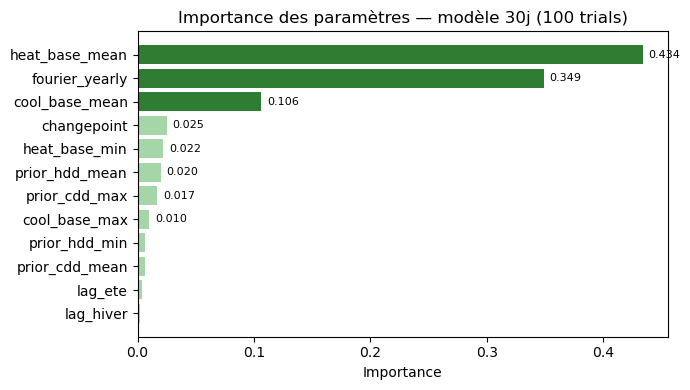

In [9]:
# Importances issues du run Optuna original (optuna.importance.get_param_importances)
importances_30j = {
    'heat_base_mean': 0.434,
    'fourier_yearly': 0.349,
    'cool_base_mean': 0.106,
    'changepoint':    0.025,
    'heat_base_min':  0.022,
    'prior_hdd_mean': 0.020,
    'prior_cdd_max':  0.017,
    'cool_base_max':  0.010,
    'prior_hdd_min':  0.006,
    'prior_cdd_mean': 0.006,
    'lag_ete':        0.004,
    'lag_hiver':      0.002,
}

labels = list(importances_30j.keys())[::-1]
values = list(importances_30j.values())[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2e7d32' if v > 0.05 else '#a5d6a7' for v in values]
ax.barh(labels, values, color=colors)
ax.set_xlabel('Importance')
ax.set_title('Importance des paramètres — modèle 30j (100 trials)')
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(values):
    if v >= 0.01:
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
fig.savefig('../figures/optuna_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Récapitulatif

| Étape | MAPE CV | Note |
|---|---|---|
| Fenêtre 2007-2025 | 5.93% | Concept drift COVID / crise énergie 2022 |
| Naïf saisonnier | 8.9% | Référence basse |
| TimesFM 200M zero-shot | 8.3% | 1 fenêtre de test, indicatif |
| Prophet seul (2023+) | 5.7% | |
| + température brute | 3.9% | |
| + HDD/CDD | 3.2% | |
| 8 villes urbaines | 5.12% | Biais îlots de chaleur |
| 4 points ruraux, poids égaux | 2.46% | |
| + poids asymétriques hiver/été | 2.47% | Pas mieux |
| + Optuna 100 trials (30j) | **2.37%** | |
| + vacances scolaires (7j) | **2.17%** | Signal noyé sur 30j |

Les paramètres finaux sont dans `src/features.py` (`BEST_PARAMS_7J`, `BEST_PARAMS_30J`).